# Multivariate LSTM model (A)

**Directly predict annualized return and volatility**

Author: Pete King

This notebook uses financial data to train a multivariate Long Short-Term Memory (LSTM) model to predict annualized return and volatility for a set of ETFs representing different market sectors.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler

import data_prep as dp
import models

# Global variables
DATA_FILENAME = 'train_val_data.csv'
TICKERS_TO_REMOVE = ['XLRE']
VALIDATION_START_DATE = '2023-01-01'
WINDOW_SIZE = 63  # Size of the rolling window used in generating the Dataset
BATCH_SIZE = 5  # For DataLoader
BUFFER_SIZE = 63  # Number of business days between train and validation sets

## I. Data Preparation

### Import and inspect financial data

In [2]:
df = pd.read_csv(
    DATA_FILENAME,
    parse_dates=True
)
df

,date,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,...,XLP_volatility_target,XLY_volatility_target,XLRE_volatility_target,BIL_volatility_target,IEF_volatility_target,TLT_volatility_target,LQD_volatility_target,HYG_volatility_target,TIP_volatility_target,GLD_volatility_target
0,1927-12-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1928-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1928-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1928-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1928-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28006,2024-07-15,29511.664,23478.57,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.090963,0.224980,0.125842,0.002766,0.056791,0.124879,0.053551,0.034949,0.036434,0.135357
28007,2024-07-16,29511.664,23478.57,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.089399,0.222424,0.127014,0.002766,0.056333,0.122062,0.052568,0.034383,0.036206,0.130409
28008,2024-07-17,29511.664,23478.57,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.086208,0.219621,0.126133,0.002766,0.056739,0.122378,0.052992,0.034429,0.036437,0.131185
28009,2024-07-18,29511.664,23478.57,120.17172,1146.182,313.569,318.94,123.736,122.911,144.922,...,0.085397,0.218482,0.124614,0.002784,0.056316,0.121168,0.052032,0.034033,0.036048,0.130300


In [3]:
# Optionally remove ETFs from the series to make more training data available
df = dp.remove_series(df, TICKERS_TO_REMOVE).dropna().copy()

### Split data into training and validation sets

In [4]:
train_df, val_df = dp.time_series_split(
    df, VALIDATION_START_DATE, BUFFER_SIZE
)

In [5]:
# Get separate lists of data (X) and label (y) columns
X_cols, y_cols = dp.get_X_y_cols(train_df, label_marker='GLD_volatility_target')

In [6]:
# Inspect the sample data to confirm start/stop dates
train_df[['date'] + X_cols]

,date,nominal_GDP,real_GDP,debt_to_GDP,debt_interest,consumer_price_index,core_PCI,personal_consumption_expenditure,core_PCE,producer_price_index,...,HG=F,NG=F,SHY,^FTSE,^GSPC,^HSI,^MOVE,^TNX,^VIX,^VXN
23379,2009-11-01,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,2.9475,5.045,66.487885,5044.600098,1036.189941,21752.869141,113.500000,3.392,30.690001,29.809999
23380,2009-11-02,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,2.9370,4.824,66.495781,5104.500000,1042.880005,21620.189453,113.699997,3.422,29.780001,29.879999
23381,2009-11-03,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,2.9480,4.922,66.487877,5037.200195,1045.410034,21240.060547,114.000000,3.473,28.809999,28.879999
23382,2009-11-04,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,2.9845,4.725,66.479851,5107.899902,1046.500000,21614.769531,116.199997,3.546,27.719999,27.889999
23383,2009-11-05,14651.249,16502.754,84.02935,353.811,217.234,220.666,89.887,89.160,100.200,...,2.9505,4.782,66.543304,5125.600098,1066.630005,21479.080078,112.699997,3.533,25.430000,25.840000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27456,2022-10-14,26770.514,22278.345,117.36678,823.106,298.007,299.399,117.919,116.204,140.681,...,3.4505,6.453,71.981956,6858.799805,3583.070068,16587.689453,152.889999,4.010,32.020000,37.750000
27457,2022-10-15,26770.514,22278.345,117.36678,823.106,298.007,299.399,117.919,116.204,140.681,...,3.4505,6.453,71.981956,6858.799805,3583.070068,16587.689453,152.889999,4.010,32.020000,37.750000
27458,2022-10-17,26770.514,22278.345,117.36678,823.106,298.007,299.399,117.919,116.204,140.681,...,3.4555,5.999,72.062073,6920.200195,3677.949951,16612.900391,150.419998,4.015,31.370001,37.070000
27459,2022-10-18,26770.514,22278.345,117.36678,823.106,298.007,299.399,117.919,116.204,140.681,...,3.4065,5.745,72.097679,6936.700195,3719.979980,16914.580078,145.789993,3.998,30.500000,36.110001


In [7]:
# Inspect dates for validation set; confirm buffer size
val_df[['date'] + y_cols]

,date,GLD_volatility_target
27524,2023-01-01,0.136638
27525,2023-01-02,0.136651
27526,2023-01-03,0.146895
27527,2023-01-04,0.145954
27528,2023-01-05,0.143354
...,...,...
28006,2024-07-15,0.135357
28007,2024-07-16,0.130409
28008,2024-07-17,0.131185
28009,2024-07-18,0.130300


### Scale data

Since our data is heterogeneous, we scale each feature to a range between \[0, 1\].  This prevents features with large values from dominating the parameter optimization process.  We fit the scaler object to the training data only, so that information about the validation set is not transfered to the training set (i.e., guard against data leakage). 

In [8]:
scaler = MinMaxScaler()
# Get scaled data (X) for training and validation
X_train = scaler.fit_transform(train_df[X_cols].values)
X_val = scaler.transform(val_df[X_cols].values)
# Get labels as NumPy array (no scaling)
y_train = train_df[y_cols].values
y_val = val_df[y_cols].values

## II. PyTorch Multivariate LSTM Model

In this section we use the PyTorch library to create Datasets and DataLoaders that we will use to introduce training samples to the LSTM model in batches.

The custom FinancialDataset implements a rolling window that captures a series of data points from time (t - L) to time (t - 1), where L is the size of the rolling window (i.e., sequence length).  Thus each data sample is a matrix with dimensions (num_features, L), where num_features is the number of features in each data instance.

The label for each data sample at time t was computed earlier using values for historical return and volatility after time t.  This forward-looking computation of the label is the reason we implement a buffer between training and validation sets -- to guard against data leakage.

### Create Datasets and DataLoaders

In [9]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),  # float32 required for LSTM
    y_train.astype(np.float32),
    window_size=WINDOW_SIZE
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),  # float32 required for LSTM
    y_val.astype(np.float32),
    window_size=WINDOW_SIZE
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [10]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([63, 58])
Shape of first training label: torch.Size([1])


In [11]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 63, 58])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

In [12]:
# Define LSTM parameters
input_size = len(X_cols)  # Number of features in data (x)
hidden_size = 128  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = False  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = WINDOW_SIZE  # Sequence length (number of timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y) for multivariate LSTM
label_size = len(y_cols)

In [13]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [14]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(58, 128)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [15]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [16]:
# Train and evaluate model
epochs = 10
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 10 epochs...
Epoch 1
Training loss:   0.033134881407022476
Validation loss: 0.04754794016480446
Epoch 2
Training loss:   0.005949638783931732
Validation loss: 0.02602144330739975
Epoch 3
Training loss:   0.005555484443902969
Validation loss: 0.028831847012043
Epoch 4
Training loss:   0.0167696513235569
Validation loss: 0.014704890549182892
Epoch 5
Training loss:   0.01459529623389244
Validation loss: 0.014546163380146027
Epoch 6
Training loss:   0.009902771562337875
Validation loss: 0.01846832036972046
Epoch 7
Training loss:   0.008740473538637161
Validation loss: 0.019462265074253082
Epoch 8
Training loss:   0.006421029567718506
Validation loss: 0.021374501287937164
Epoch 9
Training loss:   0.0045195892453193665
Validation loss: 0.02233964204788208
Epoch 10
Training loss:   0.002211388200521469
Validation loss: 0.024644192308187485


We see no clear trend for either the training loss or validation loss, with values tending to bounce around between epochs.  I have tried many (unlogged) variations with up to 100 epochs, but the validation loss consistently tends to bounce around initially and then often will steadily increase.  **Something is clearly wrong with the setup.**  Will require some troubleshooting.

Some ideas:

 1. First, fix the business day issue.  The original time series contains timestamps on Saturdays, Sundays, and other non-business days.  This could be throwing off the computations.  Certinaly, the "63 business day" gap we inted for a buffer is not actually 63 business days.
 2. Instead of predicting computed future return and volatility values, try predicting the value (price) for the ETF at the next time step.  From this predicted series, compute annualized return and volatility forecasts, then compare the forecasts to the true historical (observed) values.
 3. A multivariate LSTM may present too many dimensions/parameters with such little data.  Consider a series of single-variable LSTM models (one for each ETF), or other ways to reduce the dimensionality of the input features.
 4. As a corollary to (2) above, consider using macroeconomic variables and market sentiment indicators in some other way.  Possibly approach as an (ordinal) classification problem (i.e., predict a general "market regime").  This would serve to considerably reduce the dimensionality of the input features.  Then use the prediction as a One-Hot-Encoded input feature, or as a discrete random variable against which we compute some kind of conditional volatility/return.

## III. Analyze Results

### Plot of predictions vs labels (final epoch)


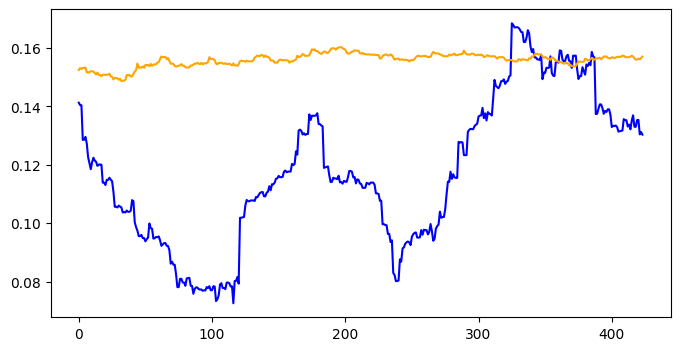

In [17]:
fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()

x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')